# Predictive Analytics and Regional Risk Classification of Staple Food Prices in the Philippines
## ML Pipeline

---
## 0. Setup & Data Loading

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Load master dataset ──────────────────────────────────────────────────────
df = pd.read_csv('final_master_dataset_fixed.csv', parse_dates=['date'])
df = df.sort_values(['adm1_name', 'cm_name', 'date']).reset_index(drop=True)

print(f'Shape           : {df.shape}')
print(f'Date range      : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Total date rows : {df["date"].nunique()} unique dates')
print(f'Regions  ({df["adm1_name"].nunique():>2}): {sorted(df["adm1_name"].unique())}')
print(f'Commodities ({df["cm_name"].nunique():>2}): {sorted(df["cm_name"].unique())}')
print(f'\nNull counts (key columns):')
print(df[['mp_price','PRECTOTCORR','T2M','primaryValue','qty']].isnull().sum())
df.head()

Shape           : (2499978, 13)
Date range      : 2000-01-01 → 2021-06-30
Total date rows : 7821 unique dates
Regions  (17): ['Autonomous region in Muslim Mindanao (ARMM)', 'Cordillera Administrative region (CAR)', 'National Capital region (NCR)', 'Region I (Ilocos region)', 'Region II (Cagayan Valley)', 'Region III (Central Luzon)', 'Region IV (Southern Tagalog)', 'Region IV-A (Calabarzon)', 'Region IX (Zamboanga Peninsula)', 'Region V (Bicol region)', 'Region VI (Western Visayas)', 'Region VII (Central Visayas)', 'Region VIII (Eastern Visayas)', 'Region X (Northern Mindanao)', 'Region XI (Davao Region)', 'Region XII (Soccsksargen)', 'Region XIII (Caraga)']
Commodities (85): ['Anchovies - Retail', 'Bananas (lakatan) - Retail', 'Bananas (latundan) - Retail', 'Bananas (saba) - Retail', 'Beans (green, fresh) - Retail', 'Beans (mung) - Retail', 'Beans (string) - Retail', 'Bitter melon - Retail', 'Bottle gourd - Retail', 'Cabbage (chinese) - Retail', 'Cabbage - Retail', 'Cabbage - Wholesal

,adm1_name,mkt_name,cm_name,year,month,mp_price,date,PRECTOTCORR,T2M,PRCP,TAVG,primaryValue,qty
0,Autonomous region in Muslim Mindanao (ARMM),Basilan,Anchovies - Retail,2020,5,200.00,2020-05-01,0.17,27.72,0.3275,82.15385,NaN,NaN
1,Autonomous region in Muslim Mindanao (ARMM),Maguindanao,Anchovies - Retail,2020,5,187.08,2020-05-01,0.17,27.72,0.3275,82.15385,NaN,NaN
2,Autonomous region in Muslim Mindanao (ARMM),Sulu,Anchovies - Retail,2020,5,106.93,2020-05-01,0.17,27.72,0.3275,82.15385,NaN,NaN
3,Autonomous region in Muslim Mindanao (ARMM),Basilan,Anchovies - Retail,2020,5,200.00,2020-05-02,0.03,27.50,0.0700,82.46154,NaN,NaN
4,Autonomous region in Muslim Mindanao (ARMM),Maguindanao,Anchovies - Retail,2020,5,187.08,2020-05-02,0.03,27.50,0.0700,82.46154,NaN,NaN


---
## 1. Advanced Feature Engineering

In [2]:
# ── 1-A  Rolling weather features (per region) ───────────────────────────────
weather_group = df.groupby('adm1_name')

for col in ['PRECTOTCORR', 'T2M']:
    df[f'{col}_roll14'] = (
        weather_group[col]
        .transform(lambda x: x.rolling(14, min_periods=1).mean())
    )
    df[f'{col}_roll30'] = (
        weather_group[col]
        .transform(lambda x: x.rolling(30, min_periods=1).mean())
    )

print('Weather rolling features:', [c for c in df.columns if 'roll' in c])

Weather rolling features: ['PRECTOTCORR_roll14', 'PRECTOTCORR_roll30', 'T2M_roll14', 'T2M_roll30']


In [3]:
# ── 1-B  Lagged price features (per region × commodity) ─────────────────────
price_group = df.groupby(['adm1_name', 'cm_name'])

for lag in [7, 14]:
    df[f'mp_price_lag{lag}'] = (
        price_group['mp_price']
        .transform(lambda x: x.shift(lag))
    )

df['price_momentum_7d'] = df['mp_price'] - df['mp_price_lag7']
print('Lagged/momentum features:', [c for c in df.columns if 'lag' in c or 'momentum' in c])

Lagged/momentum features: ['mp_price_lag7', 'mp_price_lag14', 'price_momentum_7d']


In [4]:
# ── 1-C  One-Hot Encoding ────────────────────────────────────────────────────
df_encoded = pd.get_dummies(
    df,
    columns=['adm1_name', 'cm_name'],
    drop_first=False,
    dtype=int
)

ohe_cols = [c for c in df_encoded.columns
            if c.startswith('adm1_name_') or c.startswith('cm_name_')]
print(f'Shape after OHE: {df_encoded.shape}  |  OHE columns added: {len(ohe_cols)}')

Shape after OHE: (2499978, 120)  |  OHE columns added: 102


In [12]:
# ── 1-D Finalise feature matrix ─────────────────────────

FEATURE_COLS = [
    'PRECTOTCORR', 'T2M',
    'PRECTOTCORR_roll14', 'PRECTOTCORR_roll30',
    'T2M_roll14', 'T2M_roll30',
    'mp_price_lag7', 'mp_price_lag14',
    'price_momentum_7d',
] + ohe_cols

FEATURE_COLS = [c for c in FEATURE_COLS if c in df_encoded.columns]

TARGET_COL = 'mp_price'

model_df = (
    df_encoded[FEATURE_COLS + [TARGET_COL, 'date']]
    .dropna()
    .reset_index(drop=True)
)

print(f'Modelling rows: {model_df.shape[0]:,}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Date range: {model_df["date"].min().date()} → {model_df["date"].max().date()}')

Modelling rows: 2,482,800
Features: 111
Date range: 2000-01-15 → 2021-06-30


---
## 2. Price Prediction with Random Forest

In [13]:
# ── 2-A  Time-Series Split ───────────────────────────────────────────────────
# FIX: Use positional split (last 20% of rows) instead of a fixed 100-day
# window.  This guarantees non-empty train/test even if the dataset is short.

model_df = model_df.sort_values('date').reset_index(drop=True)

n_total    = len(model_df)
TEST_SIZE  = max(50, int(n_total * 0.20))   # at least 50 rows, else 20 %
split_idx  = n_total - TEST_SIZE

train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f'Total rows : {n_total:,}')
print(f'Train      : {len(X_train):,} rows  '
      f'({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'Test       : {len(X_test):,} rows  '
      f'({test_df["date"].min().date()} → {test_df["date"].max().date()})')

assert len(X_train) > 0, 'ERROR: Training set is empty — check your dataset!'
assert len(X_test)  > 0, 'ERROR: Test set is empty — check your dataset!'

Total rows : 2,482,800
Train      : 1,986,240 rows  (2000-01-15 → 2020-12-25)
Test       : 496,560 rows  (2020-12-25 → 2021-06-30)


In [17]:
# ── 2-B Train baseline Random Forest (FAST VERSION) ───────

sample_size = 700_000   # start smaller for testing

train_sample = train_df.sample(
    n=min(sample_size, len(train_df)),
    random_state=42
)

X_train_small = train_sample[FEATURE_COLS]
y_train_small = train_sample[TARGET_COL]

print("Training rows:", len(X_train_small))

rf_baseline = RandomForestRegressor(
    n_estimators=20,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_small, y_train_small)

y_pred_baseline = rf_baseline.predict(X_test)

mae_b = mean_absolute_error(y_test, y_pred_baseline)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f'Baseline RF → MAE: {mae_b:.4f} | RMSE: {rmse_b:.4f}')

Training rows: 700000
Baseline RF → MAE: 8.0030 | RMSE: 16.0350


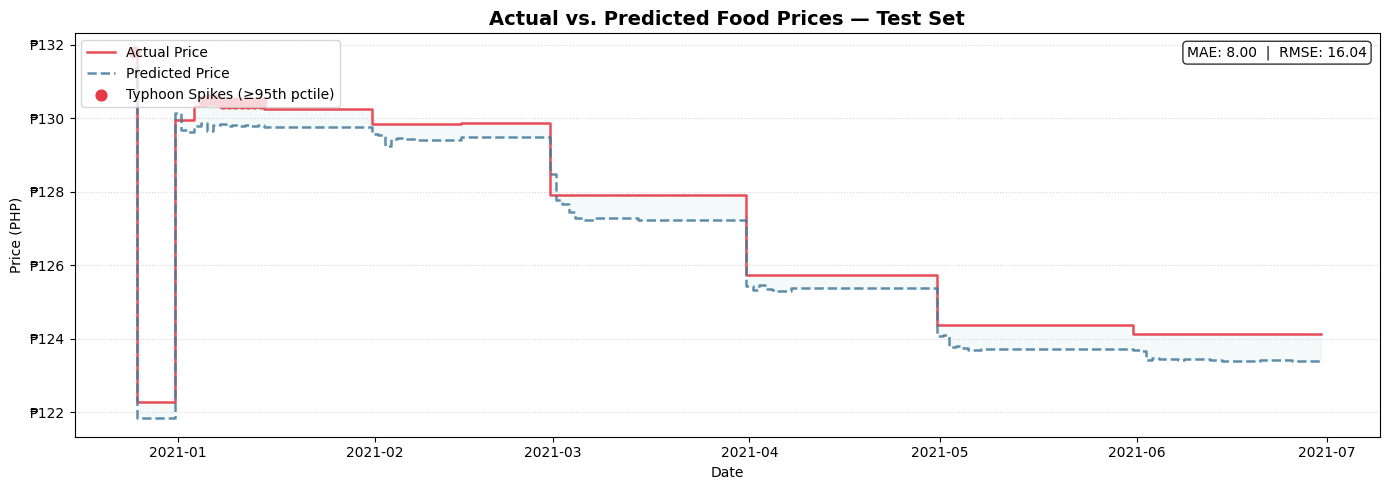

In [18]:
# ── 2-C  Step-Plot: Actual vs Predicted ──────────────────────────────────────
plot_test = test_df[['date']].copy()
plot_test['Actual']    = y_test.values
plot_test['Predicted'] = y_pred_baseline
daily = plot_test.sort_values('date').groupby('date')[['Actual','Predicted']].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.step(daily['date'], daily['Actual'],    where='mid', color='#E63946',
        linewidth=1.8, label='Actual Price', alpha=0.9)
ax.step(daily['date'], daily['Predicted'], where='mid', color='#457B9D',
        linewidth=1.8, label='Predicted Price', alpha=0.85, linestyle='--')

spike_thresh = daily['Actual'].quantile(0.95)
spikes = daily[daily['Actual'] >= spike_thresh]
ax.scatter(spikes['date'], spikes['Actual'], color='#E63946', s=60,
           zorder=5, label='Typhoon Spikes (≥95th pctile)')

ax.fill_between(daily['date'], daily['Actual'], daily['Predicted'],
                alpha=0.12, color='#A8DADC')
ax.set_title('Actual vs. Predicted Food Prices — Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP)')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))
ax.text(0.99, 0.97, f'MAE: {mae_b:.2f}  |  RMSE: {rmse_b:.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
plt.tight_layout()
plt.savefig('baseline_step_plot.png', dpi=150)
plt.show()

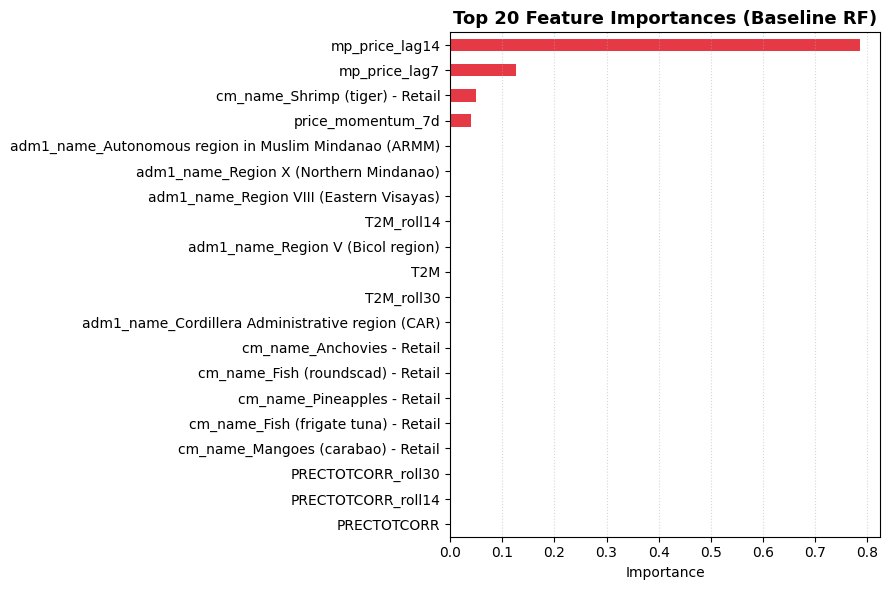

In [19]:
# ── 2-D  Feature Importance (top 20) ─────────────────────────────────────────
# FIX: rf_baseline.feature_importances_ only works AFTER .fit() — keep cells
# in order (2-B must run before 2-D).

feat_imp = pd.Series(rf_baseline.feature_importances_, index=FEATURE_COLS)
top20 = feat_imp.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E63946' if i >= 15 else '#457B9D' for i in range(len(top20))]
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 Feature Importances (Baseline RF)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

---
## 3. Regional Risk Classification (K-Means Clustering)

In [21]:
# ── 3-A Engineer clustering features per region ──────────

# Regional price volatility
price_vol = (
    df.groupby('adm1_name')['mp_price']
    .std()
    .rename('price_volatility')
)

# Regional average price
avg_price = (
    df.groupby('adm1_name')['mp_price']
    .mean()
    .rename('avg_price')
)

# Combine valid features
cluster_df = pd.concat(
    [price_vol, avg_price],
    axis=1
).dropna()

print(f'Regions available for clustering: {len(cluster_df)}')
print(cluster_df.round(4))

assert len(cluster_df) >= 3, \
    f'Need at least 3 regions for k=3 clustering, got {len(cluster_df)}.'

Regions available for clustering: 17
                                             price_volatility  avg_price
adm1_name                                                               
Autonomous region in Muslim Mindanao (ARMM)           85.4876    94.1439
Cordillera Administrative region (CAR)                94.6572   109.7231
National Capital region (NCR)                         90.8907    85.2942
Region I (Ilocos region)                              98.9582   102.3488
Region II (Cagayan Valley)                            98.3722    98.6370
Region III (Central Luzon)                           108.4282   108.1210
Region IV (Southern Tagalog)                          95.5878   113.6472
Region IV-A (Calabarzon)                             113.1164   120.4871
Region IX (Zamboanga Peninsula)                       80.5264    90.9439
Region V (Bicol region)                               92.6400   109.3142
Region VI (Western Visayas)                           83.5150    96.2553
Region VII (Ce

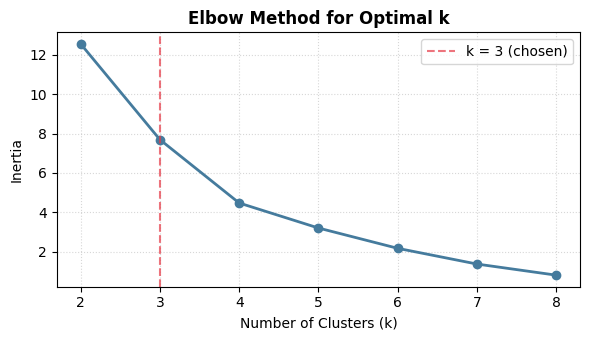

X_clust shape: (17, 2)  ✓


In [28]:
# ── 3-B  Elbow method ────────────────────────────────────────────────────────
# FIX: scaler and X_clust are defined HERE so 3-C can use them without
# NameError even if cells are run out of order.

scaler  = StandardScaler()
X_clust = scaler.fit_transform(cluster_df[['price_volatility', 'avg_price']])

max_k    = min(8, len(cluster_df) - 1)   # can't have more clusters than regions
K_range  = range(2, max_k + 1)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(K_range), inertias, marker='o', color='#457B9D', linewidth=2)
ax.axvline(3, color='#E63946', linestyle='--', alpha=0.7, label='k = 3 (chosen)')
ax.set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

print(f'X_clust shape: {X_clust.shape}  ✓')

In [27]:
# ── 3-C  Fit K-Means (k=3) & assign risk labels ──────────────────────────────
# FIX: X_clust is guaranteed to exist from the cell above.
# FIX: risk label assignment is done on a clean copy to avoid KeyError.

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df = cluster_df.copy()             # avoid SettingWithCopyWarning
cluster_df['cluster'] = km3.fit_predict(X_clust)

# Map clusters → risk levels by ranking composite score
cluster_summary = (
    cluster_df
    .groupby('cluster')[['price_volatility', 'avg_price']]
    .mean()
)
cluster_summary['risk_score'] = (
    cluster_summary['price_volatility'].rank() -
    cluster_summary['avg_price'].rank()
)

sorted_clusters = cluster_summary['risk_score'].sort_values().index.tolist()
label_map = {
    sorted_clusters[0]: 'Secure',
    sorted_clusters[1]: 'Vulnerable',
    sorted_clusters[2]: 'At Risk'
}

cluster_df['risk_level'] = cluster_df['cluster'].map(label_map)

print('Cluster → Risk mapping:', label_map)
print()
print(cluster_df[['price_volatility','avg_price','risk_level']].sort_values('risk_level'))

Cluster → Risk mapping: {0: 'Secure', 1: 'Vulnerable', 2: 'At Risk'}

                                             price_volatility   avg_price  \
adm1_name                                                                   
Region III (Central Luzon)                         108.428159  108.121014   
Region IV-A (Calabarzon)                           113.116409  120.487108   
Region XIII (Caraga)                                92.814444  107.653787   
Cordillera Administrative region (CAR)              94.657164  109.723110   
Region I (Ilocos region)                            98.958230  102.348801   
Region II (Cagayan Valley)                          98.372187   98.636971   
Region IV (Southern Tagalog)                        95.587767  113.647200   
Region V (Bicol region)                             92.640029  109.314189   
Region VIII (Eastern Visayas)                       82.187357  107.805432   
Region XI (Davao Region)                            77.043113   75.291938   
Region

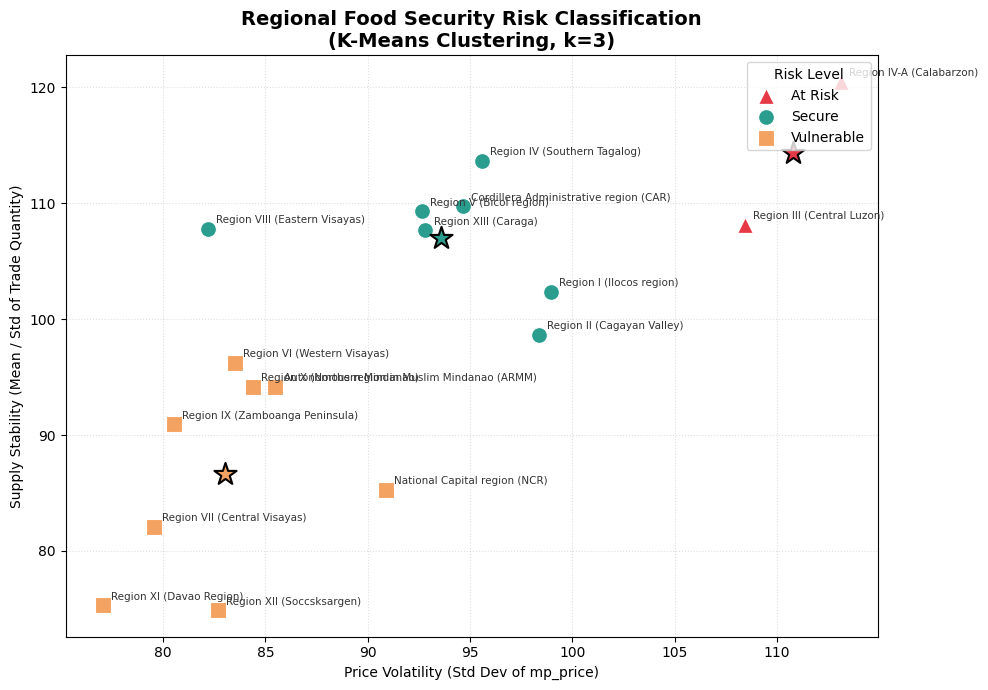

In [29]:
# ── 3-D  Cluster Scatter Plot ────────────────────────────────────────────────
RISK_COLORS  = {'Secure': '#2A9D8F', 'Vulnerable': '#F4A261', 'At Risk': '#E63946'}
RISK_MARKERS = {'Secure': 'o',       'Vulnerable': 's',       'At Risk': '^'}

fig, ax = plt.subplots(figsize=(10, 7))

for risk, grp in cluster_df.groupby('risk_level'):
    ax.scatter(
        grp['price_volatility'], grp['avg_price'],
        color=RISK_COLORS[risk], marker=RISK_MARKERS[risk],
        s=130, label=risk, edgecolors='white', linewidth=0.8, zorder=3
    )
    for region, row in grp.iterrows():
        ax.annotate(
            region,
            xy=(row['price_volatility'], row['avg_price']),
            xytext=(6, 4), textcoords='offset points',
            fontsize=7.5, color='#333333'
        )

# Cluster centroids
cents_orig = scaler.inverse_transform(km3.cluster_centers_)
for c, (cx, cy) in enumerate(cents_orig):
    risk = label_map[c]
    ax.scatter(cx, cy, color=RISK_COLORS[risk], s=280,
               edgecolors='black', linewidth=1.5, marker='*', zorder=5)

ax.set_title('Regional Food Security Risk Classification\n(K-Means Clustering, k=3)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Price Volatility (Std Dev of mp_price)')
ax.set_ylabel('Supply Stability (Mean / Std of Trade Quantity)')
ax.legend(title='Risk Level', loc='upper right', fontsize=10)
ax.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('regional_risk_clusters.png', dpi=150)
plt.show()

---
## 4. Model Fine-Tuning

In [32]:
# ── 4-0  Create 700k training sample ─────────────────────

sample_size = 700_000

train_sample = train_df.sample(
    n=min(sample_size, len(train_df)),
    random_state=42
)

X_train = train_sample[FEATURE_COLS]
y_train = train_sample[TARGET_COL]

print("Training sample size:", len(X_train))

Training sample size: 700000


In [33]:
# ── 4-A Sample weights for spike-sensitive training ──────

spike_threshold = y_train.quantile(0.95)

sample_weights = np.where(y_train >= spike_threshold,3.0,1.0)

print(f'Spike threshold (95th pctile): {spike_threshold:.2f}')
print(f'Spike samples in train: {(sample_weights == 3.0).sum():,}')
print(f'sample_weights length: {len(sample_weights)} (must match X_train: {len(X_train)})')

Spike threshold (95th pctile): 242.09
Spike samples in train: 35,009
sample_weights length: 700000 (must match X_train: 700000)


In [37]:
# ── 4-B  Hyperparameter grid search (FIXED) ─────────────────────────────

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

assert len(X_train) == len(y_train) == len(sample_weights), "Mismatch!"

# ── SPEED OPTIMIZATION SETTINGS ─────────────────────────
FAST_SAMPLE_SIZE = 700_000

idx = np.random.choice(len(X_train), FAST_SAMPLE_SIZE, replace=False)

X_fast = X_train.iloc[idx]
y_fast = y_train.iloc[idx]
w_fast = sample_weights[idx]

# ── SMALLER GRID (FAST SEARCH) ───────────────────────────
param_grid = [
    {'n_estimators': 150, 'max_depth': 10, 'min_samples_leaf': 2},
    {'n_estimators': 150, 'max_depth': 12, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 1},
]

best_mae = float("inf")
best_model = None
best_params = None

for params in param_grid:

    rf = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1,          # uses all CPU cores
        verbose=0
    )

    rf.fit(X_fast, y_fast, sample_weight=w_fast)

    pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(
        f"n_est={params['n_estimators']} depth={params['max_depth']} "
        f"leaf={params['min_samples_leaf']} → MAE={mae:.4f} RMSE={rmse:.4f}"
    )

    if mae < best_mae:
        best_mae = mae
        best_model = rf
        best_params = params

print("\n★ BEST MODEL")
print(best_params)
print("MAE:", best_mae)

n_est=150 depth=10 leaf=2 → MAE=3.8226 RMSE=9.8124
n_est=150 depth=12 leaf=2 → MAE=2.2744 RMSE=8.6288
n_est=200 depth=12 leaf=1 → MAE=2.2757 RMSE=8.5135

★ BEST MODEL
{'n_estimators': 150, 'max_depth': 12, 'min_samples_leaf': 2}
MAE: 2.274442757385058


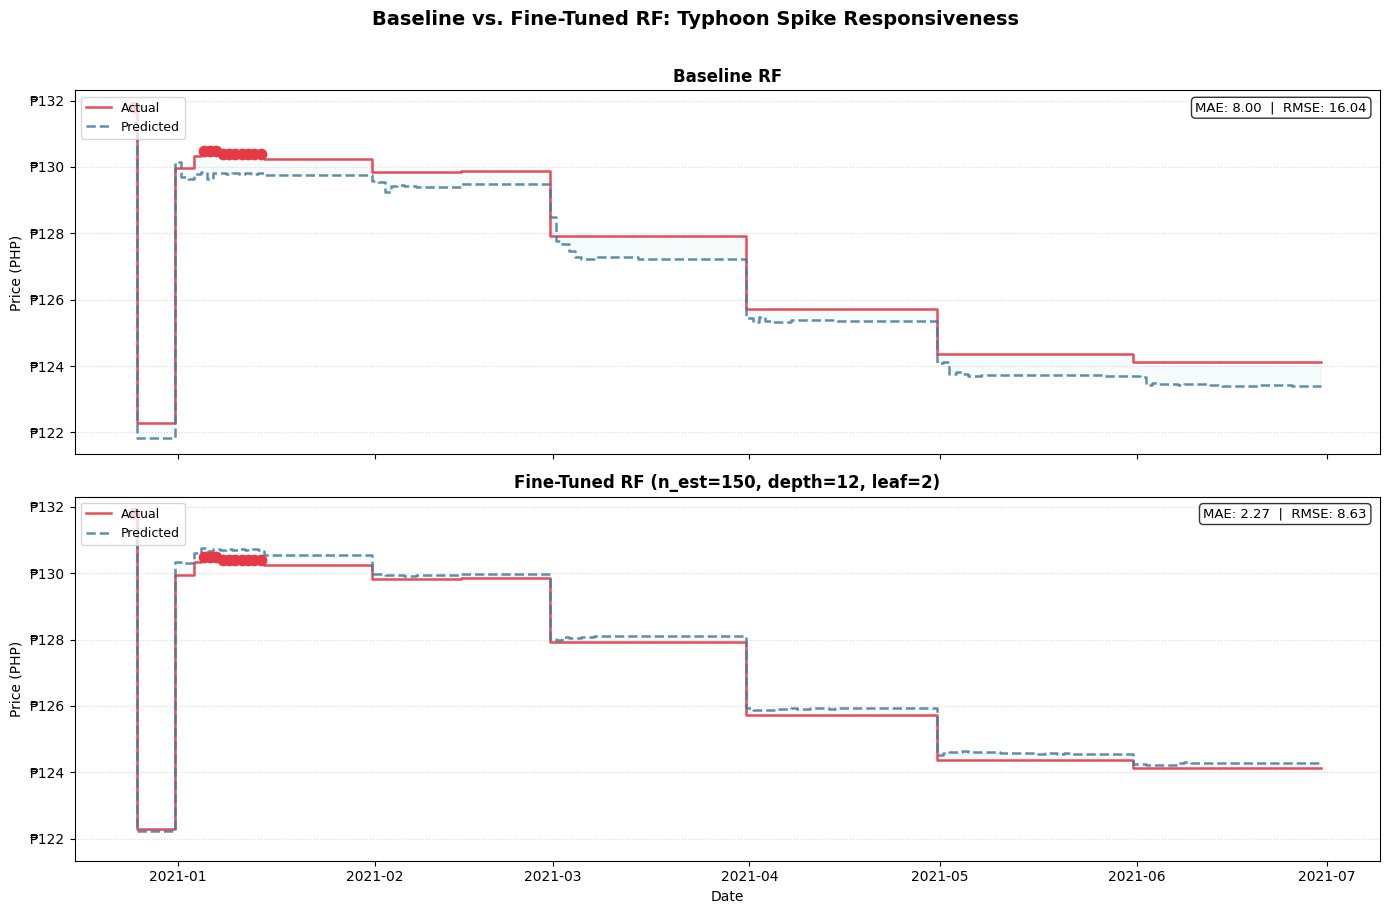

In [39]:
# ── 4-C  Side-by-side Step-Plots: Baseline vs Fine-Tuned ───────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Recompute fine-tuned predictions
y_pred_finetuned = best_model.predict(X_test)

plot_test2 = test_df[['date']].copy().reset_index(drop=True)
plot_test2['Actual']     = y_test.values
plot_test2['Baseline']   = y_pred_baseline
plot_test2['Fine-Tuned'] = y_pred_finetuned

daily2 = plot_test2.sort_values('date').groupby('date').mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, sharey=True)

titles = [
    'Baseline RF',
    f"Fine-Tuned RF (n_est={best_params['n_estimators']}, "
    f"depth={best_params['max_depth']}, leaf={best_params['min_samples_leaf']})"
]

pred_cols = ['Baseline', 'Fine-Tuned']

# recompute metrics properly
mae_b = mean_absolute_error(y_test, y_pred_baseline)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

mae_f = mean_absolute_error(y_test, y_pred_finetuned)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred_finetuned))

metrics = [(mae_b, rmse_b), (mae_f, rmse_f)]

for ax, title, pcol, (mae, rmse) in zip(axes, titles, pred_cols, metrics):

    ax.step(daily2['date'], daily2['Actual'], where='mid',
            color='#E63946', linewidth=1.8, label='Actual', alpha=0.9)

    ax.step(daily2['date'], daily2[pcol], where='mid',
            color='#457B9D', linewidth=1.8, label='Predicted',
            linestyle='--', alpha=0.85)

    spike_thresh = daily2['Actual'].quantile(0.95)
    spikes = daily2[daily2['Actual'] >= spike_thresh]

    ax.scatter(spikes['date'], spikes['Actual'],
               color='#E63946', s=55, zorder=5)

    ax.fill_between(daily2['date'], daily2['Actual'], daily2[pcol],
                    alpha=0.10, color='#A8DADC')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (PHP)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))

    ax.text(0.99, 0.97,
            f'MAE: {mae:.2f}  |  RMSE: {rmse:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

axes[-1].set_xlabel('Date')

fig.suptitle(
    'Baseline vs. Fine-Tuned RF: Typhoon Spike Responsiveness',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('finetuned_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# ── 4-D  Spike-specific metrics (FIXED) ─────────────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_test_arr = y_test.values

# spike definition (top 5%)
spike_threshold = np.quantile(y_test_arr, 0.95)
spike_mask = y_test_arr >= spike_threshold

y_spike = y_test_arr[spike_mask]

# predictions
pred_spike_b = y_pred_baseline[spike_mask]
pred_spike_ft = best_model.predict(X_test)[spike_mask]

print('=== Spike-Specific Performance (top-5% price days) ===')

print(
    f'Baseline   →  MAE: {mean_absolute_error(y_spike, pred_spike_b):.4f}  '
    f'RMSE: {np.sqrt(mean_squared_error(y_spike, pred_spike_b)):.4f}'
)

print(
    f'Fine-Tuned →  MAE: {mean_absolute_error(y_spike, pred_spike_ft):.4f}  '
    f'RMSE: {np.sqrt(mean_squared_error(y_spike, pred_spike_ft)):.4f}'
)

=== Spike-Specific Performance (top-5% price days) ===
Baseline   →  MAE: 33.7553  RMSE: 45.4866
Fine-Tuned →  MAE: 12.9528  RMSE: 27.1006


In [43]:
# ── 4-E  Save the best model ────────────────────────────────────────────────

import joblib
import pandas as pd

joblib.dump(best_model, 'rf_finetuned_model.pkl')
print('Fine-tuned model saved → rf_finetuned_model.pkl')

pd.Series(FEATURE_COLS).to_csv('feature_columns.csv', index=False)
print('Feature columns saved  → feature_columns.csv')

Fine-tuned model saved → rf_finetuned_model.pkl
Feature columns saved  → feature_columns.csv


---
## 5. Summary Dashboard

In [46]:
# ── Final summary ───────────────────────────────────────────────────────────

summary = pd.DataFrame({
    'Model': ['Baseline RF', 'Fine-Tuned RF'],
    'MAE': [mae_b, mae_f],
    'RMSE': [rmse_b, rmse_f],
    'Spike MAE': [
        mean_absolute_error(y_spike, pred_spike_b),
        mean_absolute_error(y_spike, pred_spike_ft)
    ]
})

print('=== Model Performance Summary ===')
print(summary.round(4).to_string(index=False))

print('\n=== Regional Risk Classification ===')

print(
    cluster_df[['price_volatility', 'avg_price', 'risk_level']]
    .sort_values(['risk_level', 'price_volatility'], ascending=[True, False])
    .round(4)
    .to_string()
)

=== Model Performance Summary ===
        Model    MAE    RMSE  Spike MAE
  Baseline RF 8.0030 16.0350    33.7553
Fine-Tuned RF 2.2744  8.6288    12.9528

=== Regional Risk Classification ===
                                             price_volatility  avg_price  risk_level
adm1_name                                                                           
Region IV-A (Calabarzon)                             113.1164   120.4871     At Risk
Region III (Central Luzon)                           108.4282   108.1210     At Risk
Region I (Ilocos region)                              98.9582   102.3488      Secure
Region II (Cagayan Valley)                            98.3722    98.6370      Secure
Region IV (Southern Tagalog)                          95.5878   113.6472      Secure
Cordillera Administrative region (CAR)                94.6572   109.7231      Secure
Region XIII (Caraga)                                  92.8144   107.6538      Secure
Region V (Bicol region)                    